# Combination of Numerical Model and Observations to Improve Machine Learning Predictions in a Chaotic System

This notebook explores how combining sparse, noisy observations, imperfect numerical model outputs can improve the outputs of machine learning model of a chaotic environment using the Lorenz system. GitHub Copilot was used to generate part of the code and to help with programming.

# 1. Import Required Libraries

Import libraries such as NumPy, SciPy, Matplotlib, TensorFlow/PyTorch, and others for numerical modeling, data processing, and machine learning.

In [1]:
# Import Required Libraries
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import random


# Set random seeds for reproducibility
random.seed(42)  # Python's random module
np.random.seed(42)  # NumPy
tf.random.set_seed(42)  # TensorFlow

# Ensure TensorFlow uses deterministic operations (optional, for GPU)
#import os
#os.environ['TF_DETERMINISTIC_OPS'] = '1'

2026-02-03 15:15:55.546088: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# 2. Simulate the Ground Truth System (Lorenz System)

Use an accurate ODE solver to simulate the Lorenz system and generate reference data for the chaotic environment.

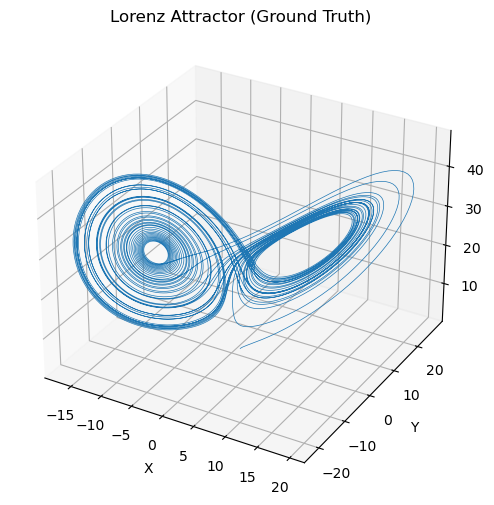

In [2]:
# Define the Lorenz system
def lorenz_system(t, state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# Simulate the Lorenz system
t_span = (0, 50)  # Time range
initial_state = [1.0, 1.0, 1.0]  # Initial conditions
t_eval = np.linspace(t_span[0], t_span[1], 10000)  # Time points for evaluation

solution = solve_ivp(lorenz_system, t_span, initial_state, t_eval=t_eval)

# Extract the solution
t = solution.t
x, y, z = solution.y

# Plot the Lorenz attractor
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
ax.plot(x, y, z, lw=0.5)
ax.set_title("Lorenz Attractor (Ground Truth)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

# 3. Create the Imperfect Numerical Model

Simulate an imperfect version of the Lorenz system by introducing parameter errors or reducing resolution.

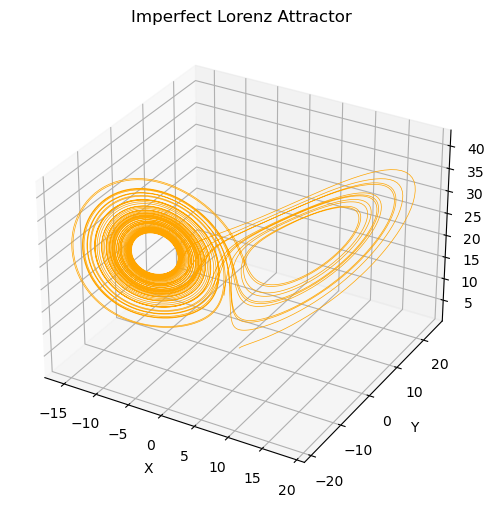

In [3]:
# Define an imperfect Lorenz system with parameter errors
def imperfect_lorenz_system(t, state, sigma=12.0, rho=25.0, beta=2.5):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# Simulate the imperfect Lorenz system
imperfect_solution = solve_ivp(imperfect_lorenz_system, t_span, initial_state, t_eval=t_eval)

# Extract the solution
x_imp, y_imp, z_imp = imperfect_solution.y

# Plot the imperfect Lorenz attractor
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
ax.plot(x_imp, y_imp, z_imp, lw=0.5, color='orange')
ax.set_title("Imperfect Lorenz Attractor")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

# 4. Generate Sparse and Noisy Observations

Sample the ground truth data sparsely and add noise to mimic real-world measurement limitations.

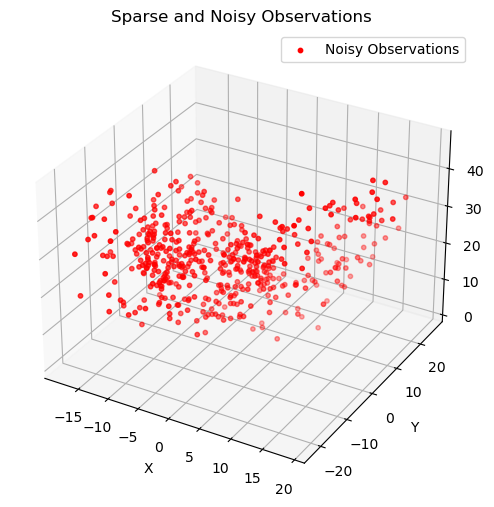

In [4]:
# Generate sparse and noisy observations
num_samples = 500  # Number of sparse samples
indices = sorted(random.sample(range(len(t)), num_samples))  # Randomly select indices
t_sparse = t[indices]
x_sparse = x[indices] + np.random.normal(0, 2.0, num_samples)  # Add noise
y_sparse = y[indices] + np.random.normal(0, 2.0, num_samples)
z_sparse = z[indices] + np.random.normal(0, 2.0, num_samples)

# Plot sparse and noisy observations
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
ax.scatter(x_sparse, y_sparse, z_sparse, c='red', s=10, label='Noisy Observations')
ax.set_title("Sparse and Noisy Observations")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()

# 5. Train Machine Learning Models to Predict the Lorenz System

In [5]:

# Import additional libraries for data preprocessing and evaluation
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Helper function to create sequences for time-series prediction
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

# Define the sequence length for LSTM input
sequence_length = 50

# Normalize the data
scaler = MinMaxScaler()
ground_truth_scaled = scaler.fit_transform(np.column_stack((x, y, z)))
imperfect_scaled = scaler.transform(np.column_stack((x_imp, y_imp, z_imp)))
observations_scaled = scaler.transform(np.column_stack((x_sparse, y_sparse, z_sparse)))

# Prepare datasets for training
X_ground_truth, y_ground_truth = create_sequences(ground_truth_scaled, sequence_length)
X_imperfect, y_imperfect = create_sequences(imperfect_scaled, sequence_length)

# Combine ground truth and imperfect data for the combined model
X_combined = np.concatenate((X_ground_truth, X_imperfect), axis=0)
y_combined = np.concatenate((y_ground_truth, y_imperfect), axis=0)

# Define and compile the LSTM model
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, activation='tanh', return_sequences=True, input_shape=input_shape),
        LSTM(64, activation='tanh'),
        Dense(3)  # Predict x, y, z
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Train the model using only observations
print("Training model with only observations...")
X_obs, y_obs = create_sequences(observations_scaled, sequence_length)
model_obs = build_lstm_model((sequence_length, 3))
model_obs.fit(X_obs, y_obs, epochs=20, batch_size=32, verbose=1)

# Train the model using only numerical model outputs
print("Training model with only numerical model outputs...")
model_num = build_lstm_model((sequence_length, 3))
model_num.fit(X_imperfect, y_imperfect, epochs=20, batch_size=32, verbose=1)

# Train the model using both sources combined
print("Training model with both sources combined...")
model_combined = build_lstm_model((sequence_length, 3))
model_combined.fit(X_combined, y_combined, epochs=20, batch_size=32, verbose=1)


Training model with only observations...
Epoch 1/20
15/15 [==============================] - 3s 20ms/step - loss: 0.0596
Epoch 2/20
15/15 [==============================] - 0s 20ms/step - loss: 0.0348
Epoch 3/20
15/15 [==============================] - 0s 20ms/step - loss: 0.0330
Epoch 4/20
15/15 [==============================] - 0s 20ms/step - loss: 0.0324
Epoch 5/20
15/15 [==============================] - 0s 21ms/step - loss: 0.0320
Epoch 6/20
15/15 [==============================] - 0s 22ms/step - loss: 0.0307
Epoch 7/20
15/15 [==============================] - 0s 22ms/step - loss: 0.0314
Epoch 8/20
15/15 [==============================] - 0s 21ms/step - loss: 0.0304
Epoch 9/20
15/15 [==============================] - 0s 21ms/step - loss: 0.0306
Epoch 10/20
15/15 [==============================] - 0s 21ms/step - loss: 0.0292
Epoch 11/20
15/15 [==============================] - 0s 21ms/step - loss: 0.0289
Epoch 12/20
15/15 [==============================] - 0s 21ms/step - loss: 0.0

Evaluating models...
311/311 [==============================] - 3s 7ms/step
Observations-only model - MSE: 0.011581403497877646
311/311 [==============================] - 3s 9ms/step
Numerical model-only model - MSE: 5.712287775527628e-05
311/311 [==============================] - 3s 8ms/step
Combined model - MSE: 1.1679962273675401e-06


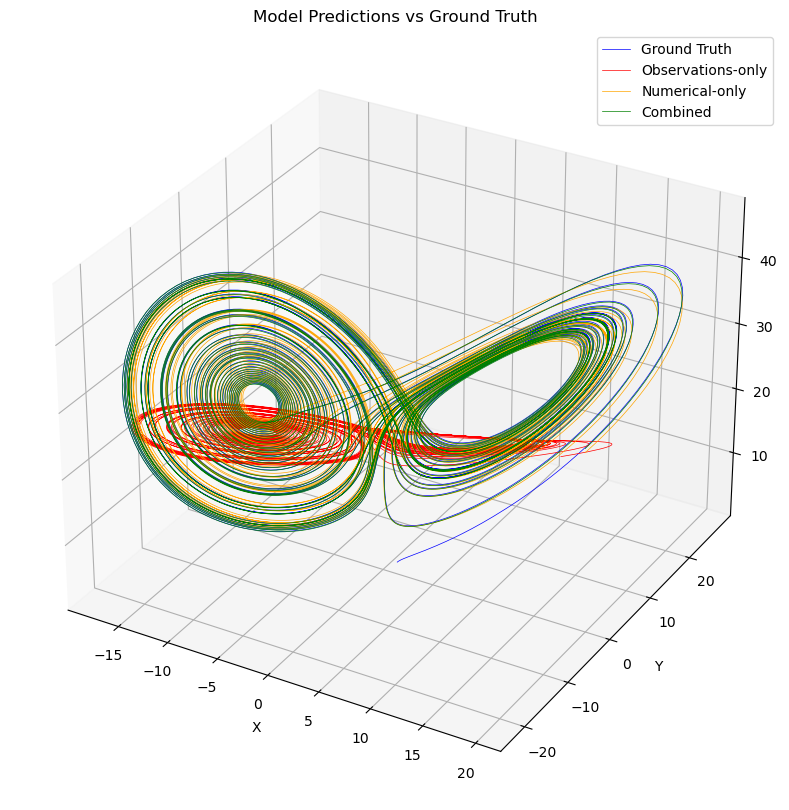

In [6]:
# Evaluate the models
def evaluate_model(model, X, y, description):
    predictions = model.predict(X)
    mse = mean_squared_error(y, predictions)
    print(f"{description} - MSE: {mse}")
    return predictions

# Evaluate all models on the ground truth data
print("Evaluating models...")
predictions_obs = evaluate_model(model_obs, X_ground_truth, y_ground_truth, "Observations-only model")
predictions_num = evaluate_model(model_num, X_ground_truth, y_ground_truth, "Numerical model-only model")
predictions_combined = evaluate_model(model_combined, X_ground_truth, y_ground_truth, "Combined model")

# Inverse transform the predictions and ground truth to the original scale
predictions_obs_original = scaler.inverse_transform(predictions_obs)
predictions_num_original = scaler.inverse_transform(predictions_num)
predictions_combined_original = scaler.inverse_transform(predictions_combined)
ground_truth_original = scaler.inverse_transform(y_ground_truth)

# Plot predictions vs ground truth
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(projection='3d')
ax.plot(x, y, z, lw=0.5, label='Ground Truth', color='blue')  # Original ground truth
ax.plot(predictions_obs_original[:, 0], predictions_obs_original[:, 1], predictions_obs_original[:, 2], 
        lw=0.5, label='Observations-only', color='red')
ax.plot(predictions_num_original[:, 0], predictions_num_original[:, 1], predictions_num_original[:, 2], 
        lw=0.5, label='Numerical-only', color='orange')
ax.plot(predictions_combined_original[:, 0], predictions_combined_original[:, 1], predictions_combined_original[:, 2], 
        lw=0.5, label='Combined', color='green')
ax.set_title("Model Predictions vs Ground Truth")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()

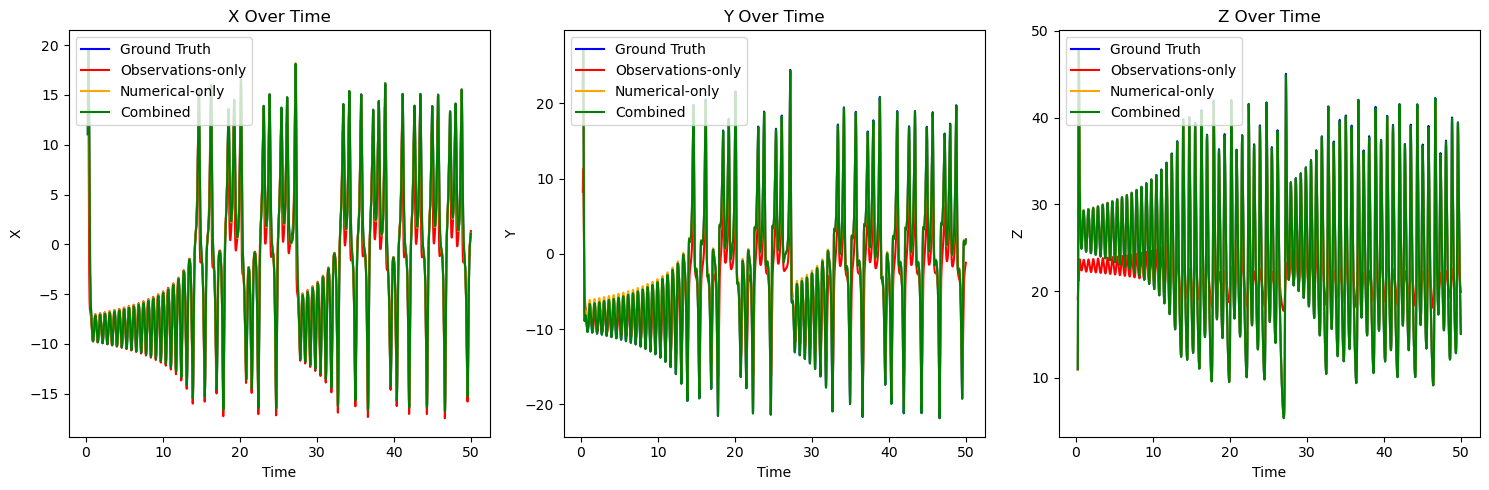

In [7]:

# 1. Compare Predictions Over Time
plt.figure(figsize=(15, 5))
for i, var in enumerate(['X', 'Y', 'Z']):
    plt.subplot(1, 3, i + 1)
    plt.plot(t[sequence_length:], ground_truth_original[:, i], label='Ground Truth', color='blue')
    plt.plot(t[sequence_length:], predictions_obs_original[:, i], label='Observations-only', color='red')
    plt.plot(t[sequence_length:], predictions_num_original[:, i], label='Numerical-only', color='orange')
    plt.plot(t[sequence_length:], predictions_combined_original[:, i], label='Combined', color='green')
    plt.title(f"{var} Over Time")
    plt.xlabel("Time")
    plt.ylabel(var)
    plt.legend()
plt.tight_layout()
plt.show()


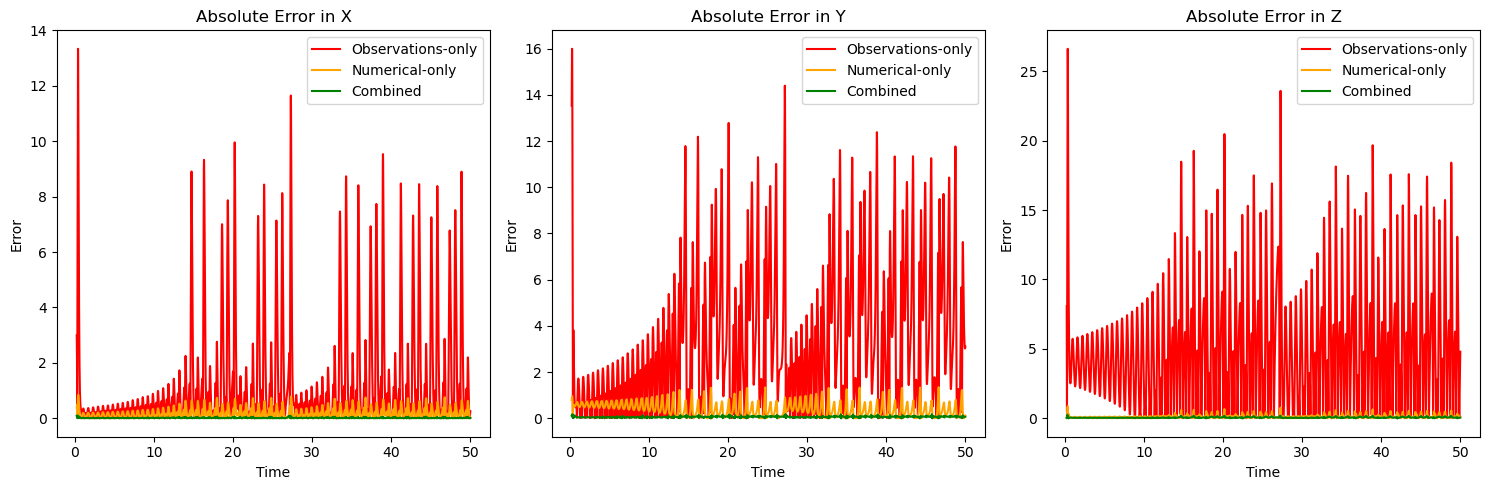

In [8]:

# 2. Error Analysis
error_obs = np.abs(ground_truth_original - predictions_obs_original)
error_num = np.abs(ground_truth_original - predictions_num_original)
error_combined = np.abs(ground_truth_original - predictions_combined_original)

plt.figure(figsize=(15, 5))
for i, var in enumerate(['X', 'Y', 'Z']):
    plt.subplot(1, 3, i + 1)
    plt.plot(t[sequence_length:], error_obs[:, i], label='Observations-only', color='red')
    plt.plot(t[sequence_length:], error_num[:, i], label='Numerical-only', color='orange')
    plt.plot(t[sequence_length:], error_combined[:, i], label='Combined', color='green')
    plt.title(f"Absolute Error in {var}")
    plt.xlabel("Time")
    plt.ylabel("Error")
    plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# 4. Quantitative Metrics Comparison
from sklearn.metrics import mean_absolute_error, r2_score, explained_variance_score

def compute_metrics(y_true, y_pred, description):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)
    print(f"{description} - MAE: {mae:.4f}, R²: {r2:.4f}, Explained Variance: {evs:.4f}")

compute_metrics(ground_truth_original, predictions_obs_original, "Observations-only model")
compute_metrics(ground_truth_original, predictions_num_original, "Numerical model-only model")
compute_metrics(ground_truth_original, predictions_combined_original, "Combined model")

# 5. Noise Sensitivity Analysis
noise_levels = [0.5, 1.0, 2.0, 5.0]
for noise in noise_levels:
    noisy_x_sparse = x[indices] + np.random.normal(0, noise, num_samples)
    noisy_y_sparse = y[indices] + np.random.normal(0, noise, num_samples)
    noisy_z_sparse = z[indices] + np.random.normal(0, noise, num_samples)
    noisy_observations_scaled = scaler.transform(np.column_stack((noisy_x_sparse, noisy_y_sparse, noisy_z_sparse)))

    X_noisy_obs, y_noisy_obs = create_sequences(noisy_observations_scaled, sequence_length)
    model_noisy_obs = build_lstm_model((sequence_length, 3))
    model_noisy_obs.fit(X_noisy_obs, y_noisy_obs, epochs=20, batch_size=32, verbose=0)

    print(f"Noise Level: {noise}")
    compute_metrics(ground_truth_original, model_noisy_obs.predict(X_ground_truth), "Noisy Observations-only model")

Observations-only model - MAE: 3.4291, R²: 0.6267, Explained Variance: 0.6879
Numerical model-only model - MAE: 0.2440, R²: 0.9984, Explained Variance: 0.9985
Combined model - MAE: 0.0410, R²: 1.0000, Explained Variance: 1.0000
Noise Level: 0.5
311/311 [==============================] - 4s 8ms/step
Noisy Observations-only model - MAE: 12.5957, R²: -3.0062, Explained Variance: 0.0258
Noise Level: 1.0
311/311 [==============================] - 3s 9ms/step
Noisy Observations-only model - MAE: 12.5916, R²: -3.0058, Explained Variance: 0.0253
Noise Level: 2.0
311/311 [==============================] - 3s 10ms/step
Noisy Observations-only model - MAE: 12.5971, R²: -3.0077, Explained Variance: 0.0255
Noise Level: 5.0
311/311 [==============================] - 3s 7ms/step
Noisy Observations-only model - MAE: 12.6101, R²: -3.0106, Explained Variance: 0.0199
